Sveučilište u Zagrebu  
Fakultet elektrotehnike i računarstva  
  
## Strojno učenje 1 2025./2026.  
http://www.fer.unizg.hr/predmet/struce1

------------------------------

### Četvrta laboratorijska vježba: Procjena parametara, probabilistički grafički modeli, grupiranje

*Verzija: 1.0
Zadnji put ažurirano: 1. listopada 2021.*

(c) 2015-2026 Jan Šnajder, Domagoj Alagić  

------------------------------

### Pravila predaje
Predajom vježbe potvrđujete sljedeće točke:
1. Niste od drugoga primili pomoć pri rješavanju vježbe;
2. Atribuirali ste dijelove koda koji su preuzeti s interneta referencirajući ih u komentarima;
3. Niste koristili dijelove koda s interneta koji su specifični za laboratorijsku vježbu;
4. Niste koristili UI-asistente za kodiranje kao npr. GitHub Copilot (uključivo alate generativne UI, kao što je ChatGPT).

**Povreda bilo kojeg od gornjih pravila smatra se prekršajem te povlači akademske sankcije.**

### Upute

Četvrta laboratorijska vježba sastoji se od osam zadataka. U nastavku slijedite upute navedene u ćelijama s tekstom. Rješavanje vježbe svodi se na **dopunjavanje ove bilježnice**: umetanja ćelije ili više njih **ispod** teksta zadatka, pisanja odgovarajućeg kôda te evaluiranja ćelija. 

Osigurajte da u potpunosti **razumijete** kôd koji ste napisali. Kod predaje vježbe, morate biti u stanju na zahtjev asistenta (ili demonstratora) preinačiti i ponovno evaluirati Vaš kôd. Nadalje, morate razumjeti teorijske osnove onoga što radite, u okvirima onoga što smo obradili na predavanju. Ispod nekih zadataka možete naći i pitanja koja služe kao smjernice za bolje razumijevanje gradiva (**nemojte pisati** odgovore na pitanja u bilježnicu). Stoga se nemojte ograničiti samo na to da riješite zadatak, nego slobodno eksperimentirajte. To upravo i jest svrha ovih vježbi.

Vježbe trebate raditi **samostalno**. Možete se konzultirati s drugima o načelnom načinu rješavanja, ali u konačnici morate sami odraditi vježbu. U protivnome vježba nema smisla.

In [97]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import silhouette_samples, silhouette_score


def plot_silhouette(n_clusters, X):
    # Kôd preuzet s http://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # FIX 1: n_init eksplicitno (makne FutureWarning)
    clusterer = KMeans(n_clusters=n_clusters, random_state=10, n_init=10)
    cluster_labels = clusterer.fit_predict(X)

    silhouette_avg = silhouette_score(X, cluster_labels)
    print("For n_clusters =", n_clusters,
          "The average silhouette_score is :", silhouette_avg)

    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    # FIX 2: novi nacin za colormap (makne MatplotlibDeprecationWarning)
    cmap = plt.get_cmap("Dark2")

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cmap(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_xlabel("Vrijednosti koeficijenta siluete")
    ax1.set_ylabel("Oznaka grupe")
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    colors = cmap(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X[:, 0], X[:, 1], marker='o', s=30, lw=0, alpha=1,
                c=colors, edgecolor='k')

    centers = clusterer.cluster_centers_
    ax2.scatter(centers[:, 0], centers[:, 1], marker='o',
                c="black", alpha=1, s=100, edgecolor='k')

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker='$%d$' % i, alpha=1,
                    s=80, edgecolor='k')

    ax2.set_xlabel(r"$x_1$")
    ax2.set_ylabel(r"$x_2$")
    plt.show()

### 1. Procjena maksimalne izglednosti

#### (a)

Definirajte funkciju izglednosti $\mathcal{L}(\mu|\mathcal{D})$ za skup $\mathcal{D}=\{x^{(i)}\}_{i=1}^N$ Bernoullijevih varijabli. Neka od $N$ varijabli njih $m$ ima vrijednost 1 (npr. od $N$ bacanja novčića, $m$ puta smo dobili glavu). Definirajte funkciju izglednosti tako da je parametrizirana s $N$ i $m$, dakle definirajte funkciju $\mathcal{L}(\mu|N,m)$. 

In [98]:
def L(mu, N, m):
    return (mu ** m) * (1 - mu)**(N - m)

#### (b)

Prikažite funkciju $\mathcal{L}(\mu|N,m)$ za (1) $N=10$ i $m=1,2,5,9$ te za (2) $N=100$ i $m=1,10,50,90$ (dva zasebna grafikona).

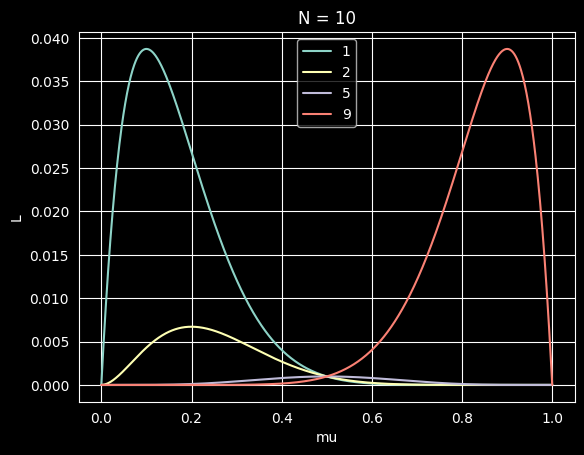

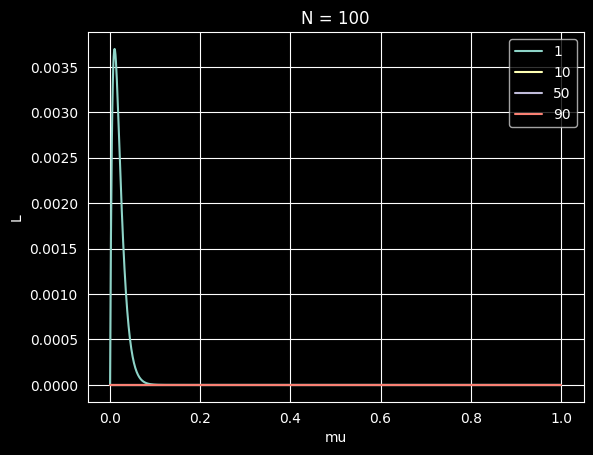

In [99]:
mu = np.linspace(1e-6, 1-1e-6, num=1001)

N= 10
for m in [1, 2, 5, 9]:
    plt.plot(mu, L(mu, N, m))
    plt.xlabel("mu")
    plt.ylabel("L")
    plt.legend([1, 2, 5, 9])
plt.title("N = 10")
plt.show()

N= 100
for m in [1, 10, 50, 90]:
    plt.plot(mu, L(mu, N, m))
    plt.xlabel("mu")
    plt.ylabel("L")
    plt.legend([1, 10, 50, 90])
plt.title("N = 100")
plt.show()

**Q:** Koja vrijednost odgovara ML-procjenama i zašto?

#### (c)

Prikažite funkciju $\mathcal{L}(\mu|N,m)$ za $N=10$ i $m=\{0,9\}$.

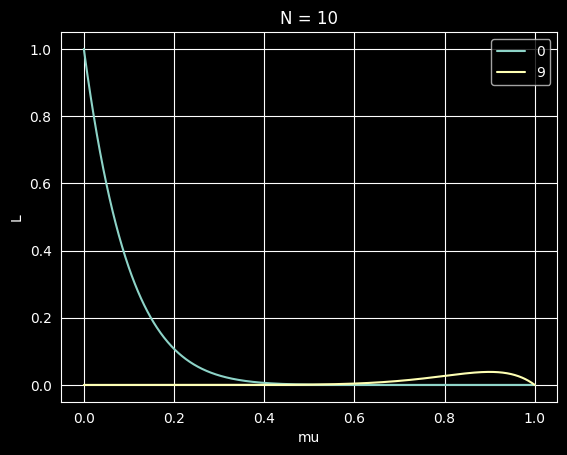

In [100]:
mu = np.linspace(1e-6, 1-1e-6, num=1001)

N= 10
for m in [0, 9]:
    plt.plot(mu, L(mu, N, m))
    plt.xlabel("mu")
    plt.ylabel("L")
    plt.legend([0, 9])
plt.title("N = 10")
plt.show()

**Q:** Koja je ML-procjena za $\mu$ i što je problem s takvom procjenom u ovome slučaju?

### 2. Procjena maksimalne aposteriorne vjerojatnosti

#### (a)

Prikažite beta-distribuciju $B(\mu|\alpha,\beta)$ za različite kombinacije parametara $\alpha$ i $\beta$, uključivo $\alpha=\beta=1$ te $\alpha=\beta=2$.

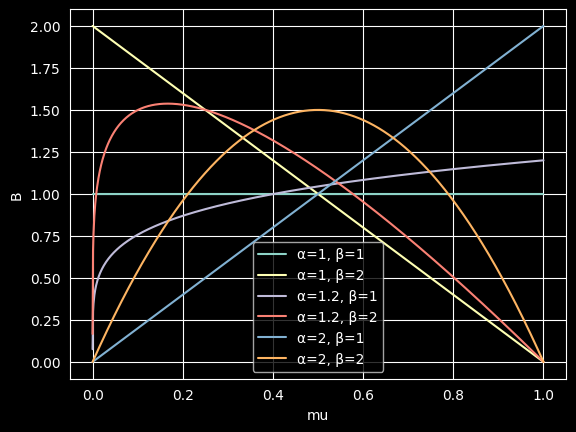

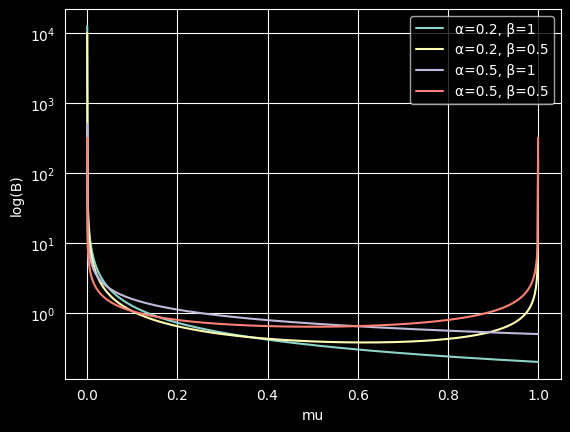

In [101]:
from itertools import product

from scipy.stats import beta

mu = np.linspace(1e-6, 1-1e-6, num=1001)

# alpha=beta >= 1 (linearno)
for a, b in product([1, 1.2, 2], [1, 2]):
    plt.plot(mu, beta(a, b).pdf(mu), label=f"α={a}, β={b}")
plt.xlabel("mu")
plt.ylabel("B")
plt.legend()
plt.show()


# alpha=beta < 1 (log y-scale)
for a, b in product([0.2, 0.5], [1, 0.5]):
    plt.plot(mu, beta(a, b).pdf(mu), label=f"α={a}, β={b}")
plt.xlabel("mu")
plt.ylabel("log(B)")
plt.yscale("log")
plt.legend()
plt.show()

**Q:** Koje parametere biste odabrali za modeliranje apriornog znanja o parametru $\mu$ za novčić za koji mislite da je "donekle pravedan, ali malo češće pada na glavu"? Koje biste parametre odabrali za novčić za koji držite da je posve pravedan? Zašto uopće koristimo beta-distribuciju, a ne neku drugu?

#### (b)

Definirajte funkciju za izračun zajedničke vjerojatnosti $P(\mu,\mathcal{D}) = P(\mathcal{D}|\mu) \cdot P(\mu|\alpha,\beta)$ te prikažite tu funkciju za $N=10$ i $m=9$ i nekolicinu kombinacija parametara $\alpha$ i $\beta$. 

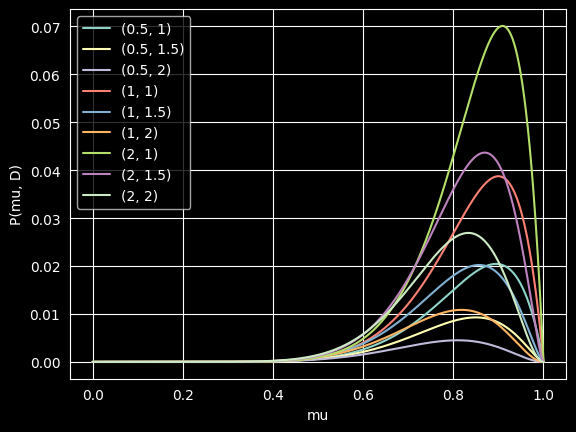

In [102]:
def join_prob(mu, N, m, a, b):
    return L(mu, N, m) * beta(a, b).pdf(mu)

N = 10
m = 9
legend = []
for a, b in product([0.5, 1, 2], [1, 1.5, 2]):
    plt.plot(mu, join_prob(mu, N, m, a, b))
    legend.append((a, b))
plt.xlabel("mu")
plt.ylabel("P(mu, D)")
plt.legend(legend)
plt.show()

**Q**: Koje vrijednosti odgovaraju MAP-procjeni za $\mu$? Usporedite ih sa ML-procjenama.

#### (c)

Za $N=10$ i $m=1$, na jednome grafikonu prikažite sve tri distribucije: $P(\mu,\mathcal{D})$, $P(\mu|\alpha,\beta)$ i $\mathcal{L}(\mu|\mathcal{D})$.

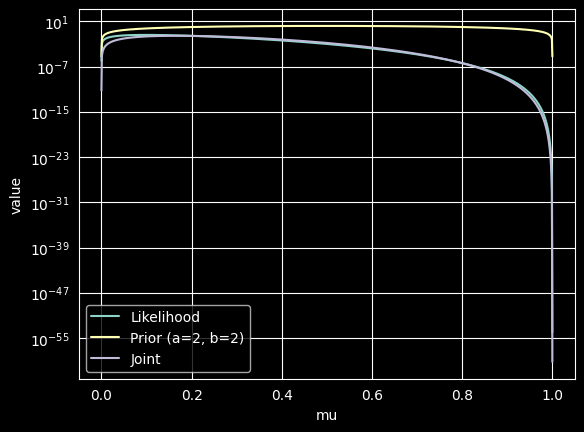

In [103]:
mu = np.linspace(1e-6, 1-1e-6, num=1001)
N = 10
m = 1

a = 2
b = 2

plt.plot(mu, L(mu, N, m), label="Likelihood")
plt.plot(mu, beta(a, b).pdf(mu), label=f"Prior (a={a}, b={b})")
plt.plot(mu, join_prob(mu, N, m, a, b), label="Joint")


plt.xlabel("mu")
plt.ylabel("value")
plt.yscale("log")
plt.legend()
plt.show()

### 3. Analiza skupa podataka *Iris*

#### (a)

Učitajte skup podataka *Iris* korištenjem funkcije [`load_iris`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html). Taj skup sadrži $n=4$ značajke i $K=3$ klase. Odaberite jednu klasu i odaberite sve primjere iz te klase, dok ostale primjere zanemarite (**u nastavku radite isključivo s primjerima iz te jedne klase**). Vizualizirajte podatke tako da načinite 2D-prikaze za svaki par značajki (šest grafikona; za prikaz je najjednostavnije koristiti funkciju [`scatter`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter)).

**NB:** Mogla bi Vam dobro dući funkcija [`itertools.combinations`](https://docs.python.org/2/library/itertools.html#itertools.combinations).

Odabrana klasa: setosa
Broj primjera u toj klasi: 50


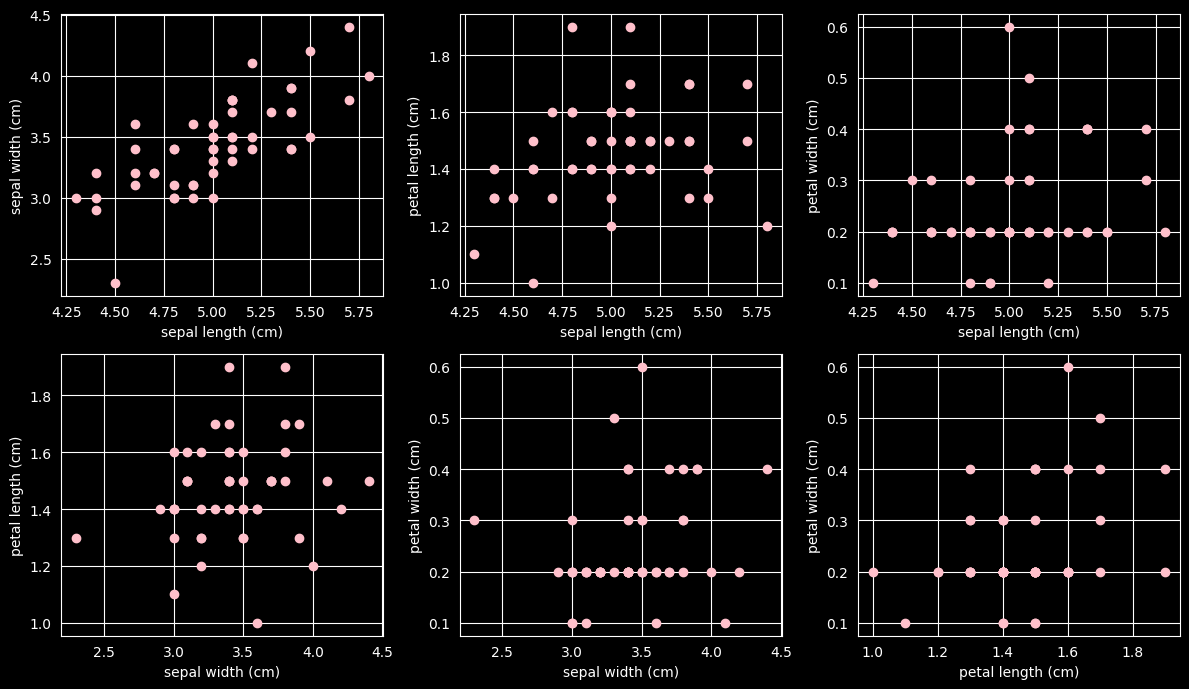

In [104]:
import itertools as it

from sklearn.datasets import load_iris

d = load_iris()
X, y = d.data, d.target
features = d.feature_names

chosen_class = 0
X = X[y == chosen_class]
print("Odabrana klasa:", d.target_names[chosen_class])
print("Broj primjera u toj klasi:", X.shape[0])

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

for ax, (i, j) in zip(axes, it.combinations(range(4), 2)):
    ax.scatter(X[:, i], X[:, j], c="pink")
    ax.set_xlabel(features[i])
    ax.set_ylabel(features[j])

plt.tight_layout()
plt.show()

#### (b)

Pogledajte opis modula [`stats`](http://docs.scipy.org/doc/scipy-0.14.0/reference/stats.html) te proučite funkciju [`norm`](http://docs.scipy.org/doc/scipy-0.14.0/reference/generated/scipy.stats.norm.html#scipy.stats.norm). Implementirajte funkciju log-izglednosti za parametre $\mu$ i $\sigma^2$ normalne distribucije.

In [105]:
from scipy.stats import norm


def logL_gauss(x, mi, sigma):
    return np.sum(norm.logpdf(x, loc=mi, scale=sigma))

#### (c)
Izračunajte ML-procjene za $(\mu, \sigma^2)$ za svaku od $n=4$ značajki iz skupa *Iris*. Ispišite log-izglednosti tih ML-procjena. 

In [106]:
for i, f in enumerate(features):
    x = X[:, i]
    mu_ml = np.mean(x)
    sigma_ml = np.std(x, ddof=0)
    log_likelihood = logL_gauss(x, mu_ml, sigma_ml)
    print(f"feature: {features[i]}")
    print(f"mu_ML = {mu_ml}")
    print(f"sigma_ML = {sigma_ml}")
    print(f"logL(mu_ML, sigma2_ML) = {log_likelihood}")
    print()

feature: sepal length (cm)
mu_ML = 5.006
sigma_ML = 0.3489469873777391
logL(mu_ML, sigma2_ML) = -18.305163312803863

feature: sepal width (cm)
mu_ML = 3.428
sigma_ML = 0.37525458025186054
logL(mu_ML, sigma2_ML) = -21.939396526466606

feature: petal length (cm)
mu_ML = 1.4620000000000002
sigma_ML = 0.17191858538273283
logL(mu_ML, sigma2_ML) = 17.089786091159766

feature: petal width (cm)
mu_ML = 0.24599999999999997
sigma_ML = 0.1043264108459598
logL(mu_ML, sigma2_ML) = 42.06460979129481



#### (d)

Proučite funkciju [`pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html) za izračun Pearsonovog koeficijenta korelacije. Izračunajte koeficijente korelacije između svih četiri značajki u skupu *Iris*. 

In [107]:
import pandas as pd
from scipy.stats import pearsonr

pearson_matrix = np.empty((4, 4))

for i in range(4):
    for j in range(4):
        pearson_matrix[i, j] = pearsonr(X[:, i], X[:, j]).statistic

pearson_df = pd.DataFrame(pearson_matrix, index=features, columns=features)
pearson_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,0.742547,0.267176,0.278098
sepal width (cm),0.742547,1.000000,0.177700,0.232752
petal length (cm),0.267176,0.177700,1.000000,0.331630
petal width (cm),0.278098,0.232752,0.331630,1.000000


#### (e)

Proučite funkciju [`cov`](http://docs.scipy.org/doc/numpy/reference/generated/numpy.cov.html) te izračunajte ML-procjenu za kovarijacijsku matricu za skup *Iris*. Usporedite pristranu i nepristranu procjenu. Pokažite da se razlika (srednja apsolutna i kvadratna) smanjuje s brojem primjera (npr. isprobajte za $N/4$ i $N/2$ i $N$ primjera).

N=50


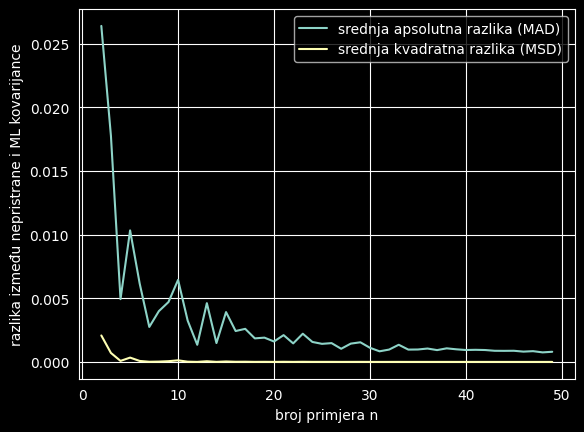

In [108]:
rng = np.random.default_rng(42)

N = X.shape[0]
mad = []
msd = []
print(f"N={N}")

for n in range(2, N):
    Xn = X[rng.choice(N, n, replace=False)]
    S_mle = np.cov(Xn, rowvar=False, ddof=0) # ML (dijeli s n)
    S_unb = np.cov(Xn, rowvar=False, ddof=1) # nepristrano (dijeli s n-1)
    D = S_unb - S_mle
    mad.append(np.mean(np.abs(D)))
    msd.append(np.mean(D**2))

plt.plot(range(2, N), mad, label="srednja apsolutna razlika (MAD)")
plt.plot(range(2, N), msd, label="srednja kvadratna razlika (MSD)")
plt.xlabel("broj primjera n")
plt.ylabel("razlika između nepristrane i ML kovarijance")
plt.legend()
plt.show()

### 4. Probabilistički grafički modeli -- Bayesove mreže

Ovaj zadatak bavit će se Bayesovim mrežama, jednim od poznatijih probabilističkih grafičkih modela (*probabilistic graphical models*; PGM). Za lakše eksperimentiranje koristit ćemo programski paket [`pgmpy`](https://github.com/pgmpy/pgmpy). Molimo Vas da provjerite imate li ovaj paket te da ga instalirate ako ga nemate. Upute se nalaze na gornjoj poveznici. Za korisnike Anaconde, najlakše je upisati `conda install -c ankurankan pgmpy` (ili `pip install pgmpy` ako ne prolazi) unutar Anaconda Prompta (i ponovno pokrenuti Jupyter).

Prvo ćemo pogledati udžbenički primjer s prskalicom. U ovom primjeru razmatramo Bayesovu mrežu koja modelira zavisnosti između oblačnosti (slučajna varijabla $C$), kiše ($R$), prskalice ($S$) i mokre trave ($W$). U ovom primjeru također pretpostavljamo da već imamo parametre vjerojatnosnih distribucija svih čvorova. Ova mreža prikazana je na sljedećoj slici:

![This](http://www.fer.unizg.hr/_download/repository/bayes-net-sprinkler.jpg)

Koristeći paket `pgmpy`, konstruirajte Bayesovu mrežu iz gornjeg primjera. Zatim, koristeći **egzaktno** zaključivanje, postavite sljedeće posteriorne upite: $P(w=1)$, $P(s=1|w=1)$, $P(r=1|w=1)$, $P(c=1|s=1, r=1)$ i $P(c=1)$. Provedite zaključivanje na papiru i uvjerite se da ste ispravno konstruirali mrežu. Pomoći će vam službena dokumentacija te primjeri korištenja (npr. [ovaj](https://github.com/pgmpy/pgmpy/blob/dev/examples/Monty%20Hall%20Problem.ipynb)).

In [109]:
# moro sam promjenit u DiscreteBayesianNetwork jer je u biljzenci bila neka depricated verzija modela
from pgmpy.factors.discrete.CPD import TabularCPD
from pgmpy.inference.ExactInference import VariableElimination
from pgmpy.models.DiscreteBayesianNetwork import DiscreteBayesianNetwork

In [110]:
network = DiscreteBayesianNetwork([("C","S"), ("C","R"), ("S","W"), ("R","W")])

cpds = []
cpds.append(TabularCPD("C", 2, [[0.5],[0.5]]))

cpds.append(TabularCPD("S", 2,
                   [[0.50, 0.90],   # P(S=0|C=0), P(S=0|C=1)
                    [0.50, 0.10]],  # P(S=1|C=0), P(S=1|C=1)
                   evidence=["C"], evidence_card=[2]))

cpds.append(TabularCPD("R", 2,
                   [[0.80, 0.20],   # P(R=0|C=0), P(R=0|C=1)
                    [0.20, 0.80]],  # P(R=1|C=0), P(R=1|C=1)
                   evidence=["C"], evidence_card=[2]))

# stupci su: (S,R) = (0,0),(0,1),(1,0),(1,1)
cpds.append(TabularCPD("W", 2,
                   [[1.00, 0.10, 0.10, 0.01],  # P(W=0|S,R)
                    [0.00, 0.90, 0.90, 0.99]], # P(W=1|S,R)
                   evidence=["S","R"], evidence_card=[2,2]))

network.add_cpds(*cpds)

# egzaktno zaključivanje
infer = VariableElimination(network)

qW = infer.query(["W"])
print("P(W) =", qW.values, " -> P(W=1) =", float(qW.values[1]))

print("P(S=1|W=1) =", float(infer.query(["S"], evidence={"W":1}).values[1]))
print("P(R=1|W=1) =", float(infer.query(["R"], evidence={"W":1}).values[1]))
print("P(C=1|S=1,R=1) =", float(infer.query(["C"], evidence={"S":1,"R":1}).values[1]))
print("P(C=1) =", float(infer.query(["C"]).values[1]))

P(W) = [0.3529 0.6471]  -> P(W=1) = 0.6471
P(S=1|W=1) = 0.4297635605006954
P(R=1|W=1) = 0.7079276773296245
P(C=1|S=1,R=1) = 0.4444444444444445
P(C=1) = 0.5


**Q:** Koju zajedničku vjerojatnosnu razdiobu ova mreža modelira? Kako tu informaciju očitati iz mreže?  
**Q:** U zadatku koristimo egzaktno zaključivanje. Kako ono radi?  
**Q:** Koja je razlika između posteriornog upita i MAP-upita?  
**Q:** Zašto je vjerojatnost $P(c=1)$ drugačija od $P(c=1|s=1,r=1)$ ako znamo da čvorovi $S$ i $R$ nisu roditelji čvora $C$?

### 5. Efekt objašnjavanja

 **Efekt objašnjavanja** (engl. *explaining away*) zanimljiv je fenomen u kojem se događa da se dvije varijable "natječu" za objašnjavanje treće. Ovaj fenomen može se primijetiti na gornjoj mreži. U tom se slučaju varijable prskalice ($S$) i kiše ($R$) "natječu" za objašnjavanje mokre trave ($W$). Vaš zadatak je pokazati da se fenomen zaista događa.

In [111]:
pS = float(infer.query(["S"]).values[1])
pR = float(infer.query(["R"]).values[1])

pS_w   = float(infer.query(["S"], evidence={"W": 1}).values[1])
pS_w_r = float(infer.query(["S"], evidence={"W": 1, "R": 1}).values[1])

pR_w   = float(infer.query(["R"], evidence={"W": 1}).values[1])
pR_w_s = float(infer.query(["R"], evidence={"W": 1, "S": 1}).values[1])

print(f"P(S=1) = {pS:.2f}")
print(f"P(S=1|W=1) = {pS_w:.2f}")
print(f"P(S=1|W=1,R=1) = {pS_w_r:.2f}   <- trebalo bi biti MANJE od P(S=1|W=1)")
print()
print(f"P(R=1) = {pR:.2f}")
print(f"P(R=1|W=1) = {pR_w:.2f}")
print(f"P(R=1|W=1,S=1) = {pR_w_s:.2f}   <- trebalo bi biti MANJE od P(R=1|W=1)")

P(S=1) = 0.30
P(S=1|W=1) = 0.43
P(S=1|W=1,R=1) = 0.19   <- trebalo bi biti MANJE od P(S=1|W=1)

P(R=1) = 0.50
P(R=1|W=1) = 0.71
P(R=1|W=1,S=1) = 0.32   <- trebalo bi biti MANJE od P(R=1|W=1)


**Q:** Kako biste svojim riječima opisali ovaj fenomen, koristeći se ovim primjerom?

### 6. Algoritam k-sredina

U ovom zadatku ćete se upoznati s algoritmom k-sredina (engl. *k-means*), njegovim glavnim nedostatcima te pretpostavkama.

#### (a)  
Jedan od nedostataka algoritma k-sredina jest taj što unaprijed zahtjeva broj grupa ($K$) u koje će grupirati podatke. Ta informacija nam često nije dostupna (kao što nam nisu dostupne ni oznake primjera) te je stoga potrebno nekako izabrati najbolju vrijednost hiperparametra $K$. Jedan od naivnijih pristupa jest **metoda lakta/koljena** (engl. *elbow method*) koju ćete isprobati u ovom zadatku.

U svojim rješenjima koristite ugrađenu implementaciju algoritma k-sredina, dostupnoj u razredu [`cluster.KMeans`](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html). 

**NB**: Kriterijska funkcija algoritma k-sredina još se i naziva **inercijom** (engl. *inertia*). Za naučeni model, vrijednost kriterijske funkcije $J$ dostupna je kroz razredni atribut `inertia_`.

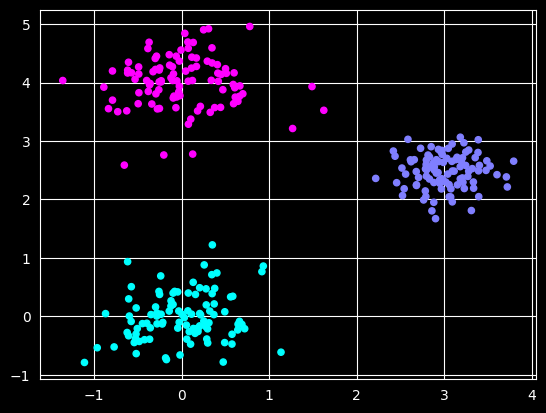

In [112]:
from sklearn.datasets import make_blobs

Xp, yp = make_blobs(n_samples=300, n_features=2, centers=[[0, 0], [3, 2.5], [0, 4]], 
                    cluster_std=[0.45, 0.3, 0.45], random_state=96)
plt.scatter(Xp[:,0], Xp[:,1], c=yp, cmap=plt.get_cmap("cool"), s=20)
plt.show()

Iskoristite skup podataka `Xp` dan gore. Isprobajte vrijednosti hiperparametra $K$ iz $[0,1,\ldots,15]$. Ne trebate dirati nikakve hiperparametre modela osim $K$. Iscrtajte krivulju od $J$ u ovisnosti o broju grupa $K$. Metodom lakta/koljena odredite vrijednost hiperparametra $K$.

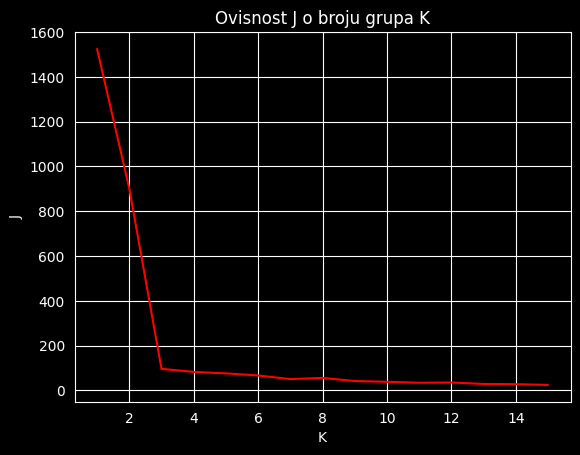

In [113]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 16):
    model = KMeans(n_clusters=k, n_init="auto")
    model.fit(Xp)
    inertia.append(model.inertia_)

plt.plot(range(1, 16), inertia, c="r")
plt.title("Ovisnost J o broju grupa K")
plt.xlabel("K")
plt.ylabel("J")
plt.show()

**Q:** Koju biste vrijednost hiperparametra $K$ izabrali na temelju ovog grafa? Zašto? Je li taj odabir optimalan? Kako to znate?    
**Q:** Je li ova metoda robusna?  
**Q:** Možemo li izabrati onaj $K$ koji minimizira pogrešku $J$? Objasnite.

#### (b)  
Odabir vrijednosti hiperparametra $K$ može se obaviti na mnoštvo načina. Pored metode lakta/koljena, moguće je isto ostvariti i analizom siluete (engl. *silhouette analysis*). Za to smo pripremili funkciju `plot_silhouette` koja za dani broj grupa i podatke iscrtava prosječnu vrijednost koeficijenta siluete i vrijednost koeficijenta svakog primjera (kroz grupe). 

Vaš je zadatak isprobati različite vrijednosti hiperparametra $K$, $K \in \{2, 3, 5\}$ i na temelju dobivenih grafova odlučiti se za optimalan $K$.

For n_clusters = 2 The average silhouette_score is : 0.59280796169837


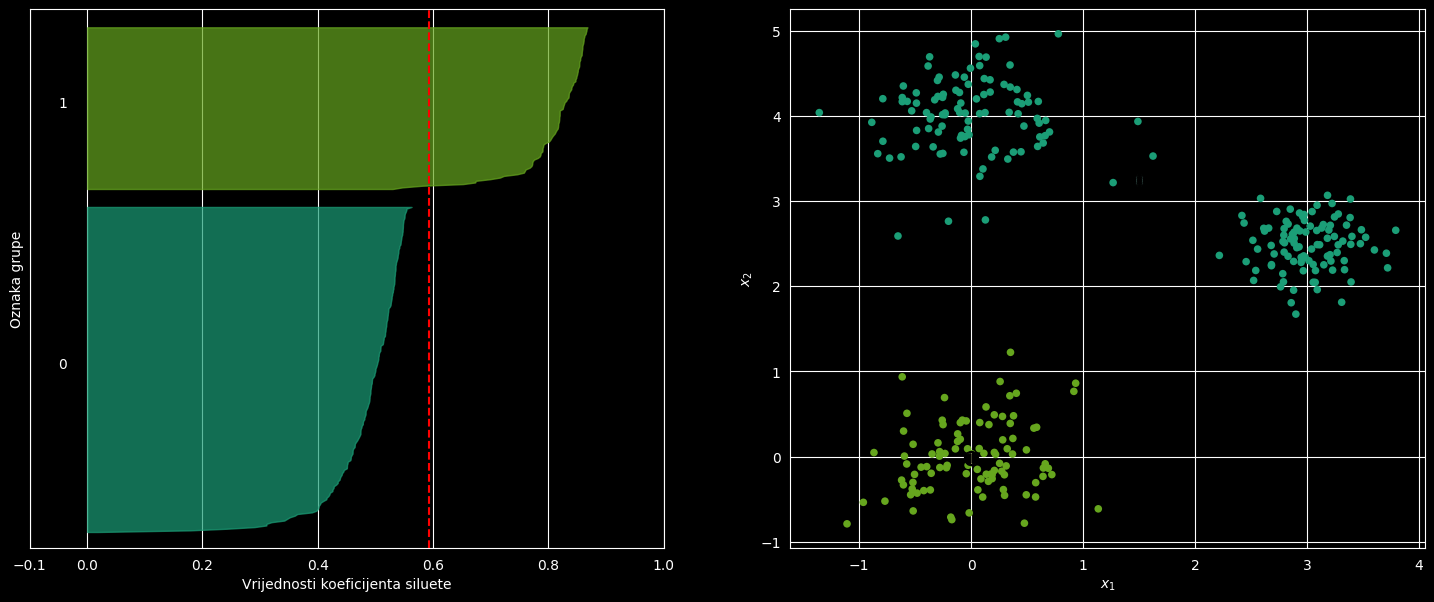

For n_clusters = 3 The average silhouette_score is : 0.7975462212061405


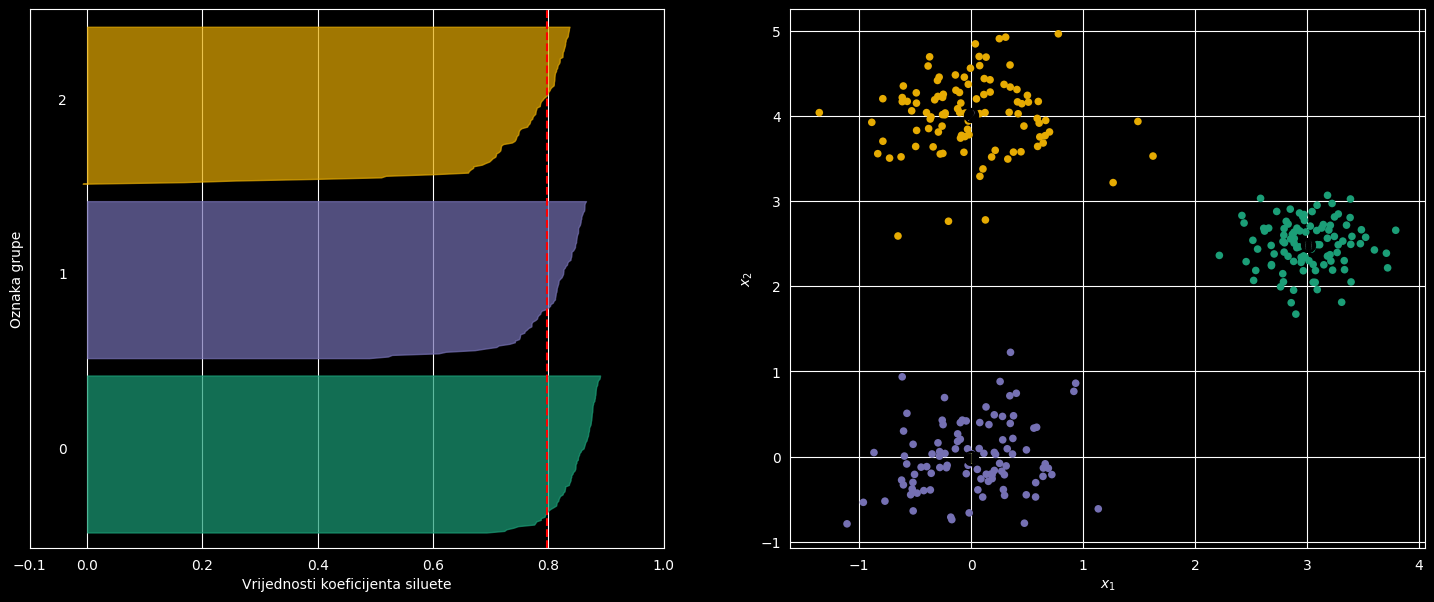

For n_clusters = 5 The average silhouette_score is : 0.5059026123508755


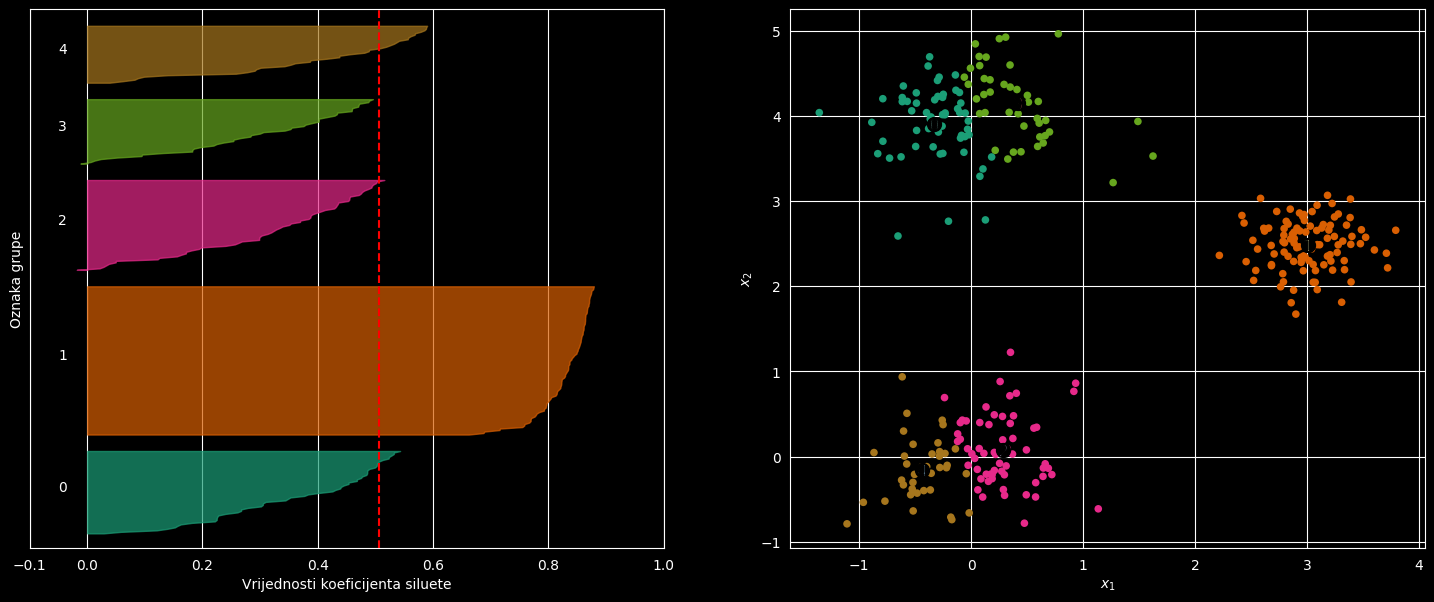

In [114]:
for k in [2, 3, 5]:
    plot_silhouette(k, Xp)

**Q:** Kako biste se gledajući ove slike odlučili za $K$?  
**Q:** Koji su problemi ovog pristupa?

#### (c)  
U ovom i sljedećim podzadatcima fokusirat ćemo se na temeljne pretpostavke algoritma k-sredina te što se događa ako te pretpostavke nisu zadovoljene. 

Prvo, krenite od podataka `X1`, koji su generirani korištenjem funkcije [`datasets.make_blobs`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html), koja stvara grupe podataka pomoću izotropskih Gaussovih distribucija.

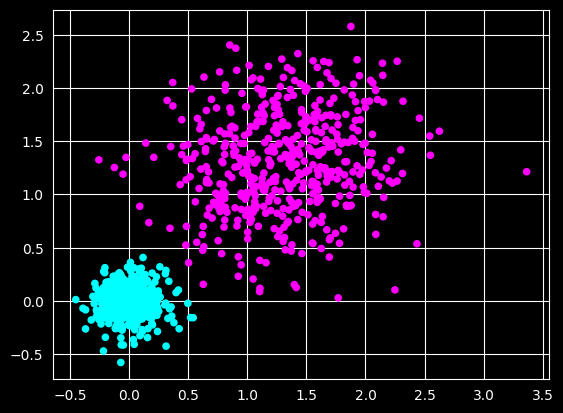

In [115]:
from sklearn.datasets import make_blobs

X1, y1 = make_blobs(n_samples=1000, n_features=2, centers=[[0, 0], [1.3, 1.3]], cluster_std=[0.15, 0.5], random_state=96)
plt.scatter(X1[:,0], X1[:,1], c=y1, cmap=plt.get_cmap("cool"), s=20)
plt.show()

Naučite model k-sredina (idealno pretpostavljajući $K=2$) na gornjim podatcima i prikažite dobiveno grupiranje (proučite funkciju [`scatter`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter), posebice argument `c`).

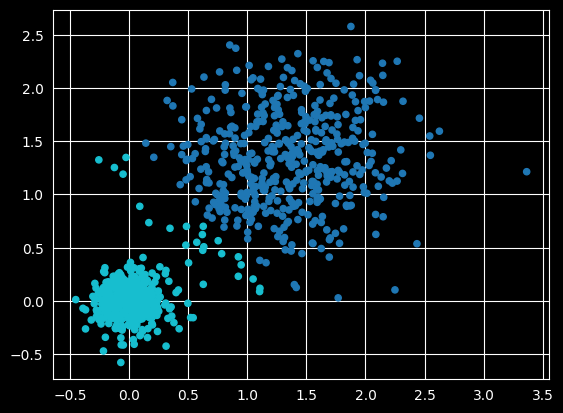

In [116]:
y = KMeans(n_clusters=2, random_state=42, n_init="auto").fit_predict(X1)
plt.scatter(X1[:,0], X1[:,1], c=y, cmap="tab10", s=20)
plt.show()

**Q:** Što se dogodilo? Koja je pretpostavka algoritma k-sredina ovdje narušena?  
**Q:** Što biste morali osigurati kako bi algoritam pronašao ispravne grupe?

#### (d)

Isprobajte algoritam k-sredina na podatcima generiranim korištenjem funkcije [`datasets.make_circles`](http://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html), koja stvara dvije grupe podataka tako da je jedna unutar druge.

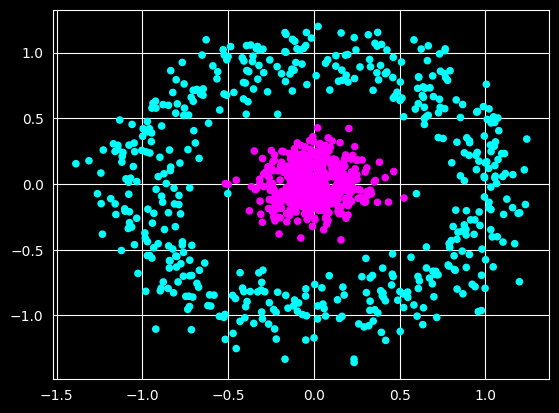

In [117]:
from sklearn.datasets import make_circles

X2, y2 = make_circles(n_samples=1000, noise=0.15, factor=0.05, random_state=96)
plt.scatter(X2[:,0], X2[:,1], c=y2, cmap=plt.get_cmap("cool"), s=20)
plt.show()

Ponovno, naučite model k-sredina (idealno pretpostavljajući $K=2$) na gornjim podatcima i prikažite dobiveno grupiranje (proučite funkciju [`scatter`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter), posebice argument `c`).

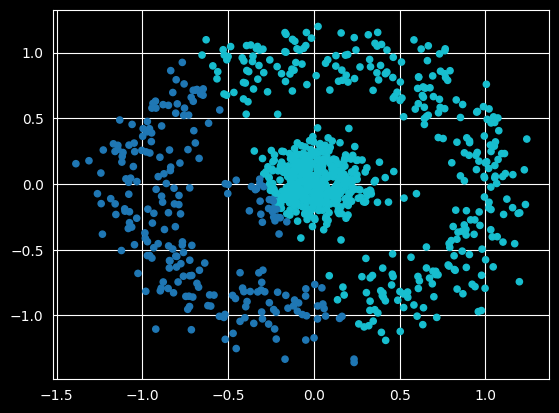

In [118]:
y = KMeans(n_clusters=2, random_state=42, n_init="auto").fit_predict(X2)
plt.scatter(X2[:,0], X2[:,1], c=y, cmap="tab10", s=20)
plt.show()

**Q:** Što se dogodilo? Koja je pretpostavka algoritma k-sredina ovdje narušena?  
**Q:** Što biste morali osigurati kako bi algoritam pronašao ispravne grupe?

#### (e)  
Završno, isprobat ćemo algoritam na sljedećem umjetno stvorenom skupu podataka:

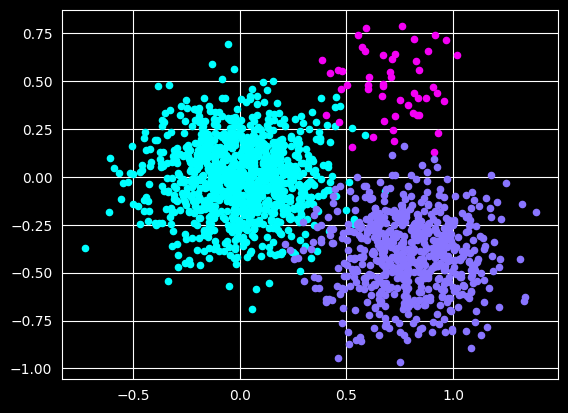

In [119]:
X31, y31 = make_blobs(n_samples=1000, n_features=2, centers=[[0, 0]], cluster_std=[0.2], random_state=69)
X32, y32 = make_blobs(n_samples=50, n_features=2, centers=[[0.7, 0.5]], cluster_std=[0.15], random_state=69)
X33, y33 = make_blobs(n_samples=600, n_features=2, centers=[[0.8, -0.4]], cluster_std=[0.2], random_state=69)
plt.scatter(X31[:,0], X31[:,1], c="#00FFFF", s=20)
plt.scatter(X32[:,0], X32[:,1], c="#F400F4", s=20)
plt.scatter(X33[:,0], X33[:,1], c="#8975FF", s=20)
plt.show()

# Just join all the groups in a single X.
X3 = np.vstack([X31, X32, X33])
y3 = np.hstack([y31, y32, y33])

Ponovno, naučite model k-sredina (ovaj put idealno pretpostavljajući $K=3$) na gornjim podatcima i prikažite dobiveno grupiranje (proučite funkciju [`scatter`](http://matplotlib.org/api/pyplot_api.html#matplotlib.pyplot.scatter), posebice argument `c`).

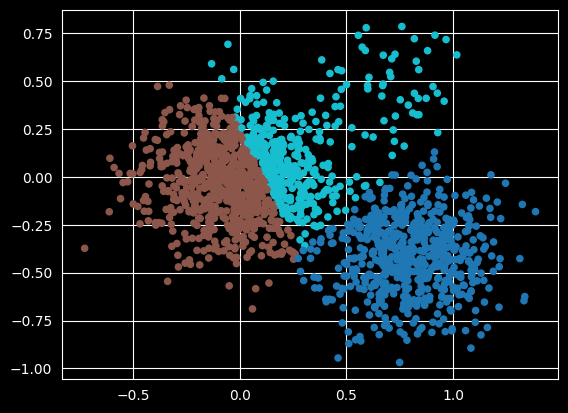

In [120]:
y = KMeans(n_clusters=3, random_state=42, n_init="auto").fit_predict(X3)
plt.scatter(X3[:,0], X3[:,1], c=y, cmap="tab10", s=20)
plt.show()

**Q:** Što se dogodilo? Koja je pretpostavka algoritma k-sredina ovdje narušena?  
**Q:** Što biste morali osigurati kako bi algoritam pronašao ispravne grupe?

### 7. Model Gaussovih mješavina

Sada kada ste se upoznali s ograničenjima algoritma k-sredina, isprobat ćete grupiranje modelom mješavine Gaussa (*Gaussian Mixture Models; GMM*), koji je generalizacija algoritma k-sredina (odnosno, algoritam k-sredina specijalizacija je GMM-a). Implementacija ovog modela dostupna je u [`mixture.GaussianMixture`](http://scikit-learn.org/stable/modules/generated/sklearn.mixture.GaussianMixture.html). Isprobajte ovaj model (s istim pretpostavkama o broju grupa) na podacima iz podzadataka (c)-(e). Ne morate mijenjati nikakve hiperparametre ni postavke osim broja komponenti.

In [121]:
from sklearn.mixture import GaussianMixture

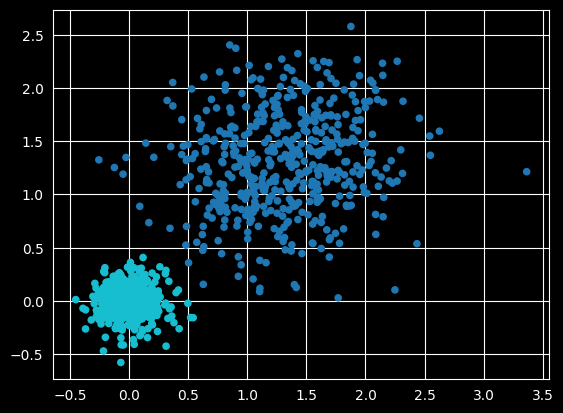

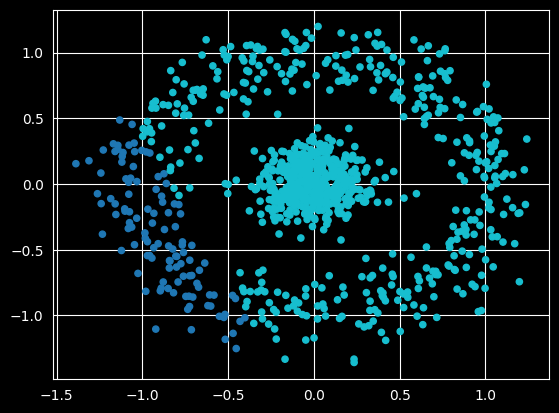

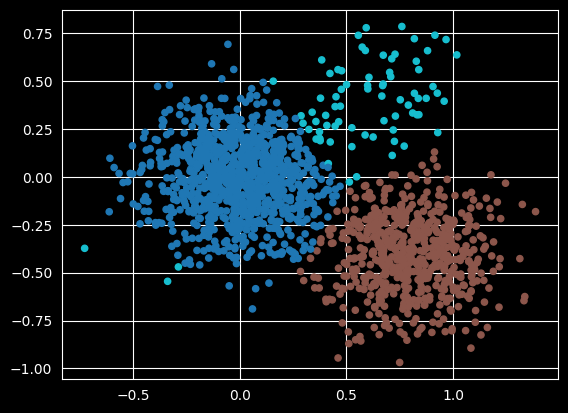

In [122]:

y = GaussianMixture(n_components=2, random_state=42, n_init=10).fit_predict(X1)
plt.scatter(X1[:,0], X1[:,1], c=y, cmap="tab10", s=20)
plt.show()

y = GaussianMixture(n_components=2, random_state=42, n_init=10).fit_predict(X2)
plt.scatter(X2[:,0], X2[:,1], c=y, cmap="tab10", s=20)
plt.show()

y = GaussianMixture(n_components=3, random_state=42, n_init=10).fit_predict(X3)
plt.scatter(X3[:,0], X3[:,1], c=y, cmap="tab10", s=20)
plt.show()


### 8. Vrednovanje grupiranja

Kako vrednovati točnost modela grupiranja ako imamo stvarne oznake svih primjera (a u našem slučaju imamo, jer smo mi ti koji smo generirali podatke)? Često korištena mjera jest **Randov indeks** koji je zapravo pandan točnosti u zadatcima klasifikacije. Implementirajte funkciju `rand_index_score(y_gold, y_predict)` koja ga računa. Funkcija prima dva argumenta: listu stvarnih grupa kojima primjeri pripadaju (`y_gold`) i listu predviđenih grupa (`y_predict`). Dobro će vam doći funkcija [`itertools.combinations`](https://docs.python.org/2/library/itertools.html#itertools.combinations).

In [123]:
from itertools import combinations


def rand_index_score(y_gold, y_predict):
    tp = tn = fp = fn = 0
    for i, j in combinations(range(len(y_gold)), 2):
        match (bool(y_gold[i] == y_gold[j]), bool(y_predict[i] == y_predict[j])):
            case (True, True):   tp += 1
            case (False, False): tn += 1
            case (False, True):  fp += 1
            case (True, False):  fn += 1
    denom = tp + tn + fp + fn
    return (tp + tn) / denom if denom else 1.0

In [125]:
from sklearn.metrics.cluster import rand_score

print("ugradeni randov score:", rand_score(y2, GaussianMixture(n_components=2, random_state=42, n_init=10).fit_predict(X2)))

print("moj implementirani randov score:", rand_index_score(y2, GaussianMixture(n_components=2, random_state=42, n_init=10).fit_predict(X2)))

ugradeni randov score: 0.525063063063063
moj implementirani randov score: 0.525063063063063


**Q:** Zašto je Randov indeks pandan točnosti u klasifikacijskim problemima?  
**Q:** Koji su glavni problemi ove metrike?   
**Q:** Kako vrednovati kvalitetu grupiranja ako nenamo stvarne oznake primjera? Je li to uopće moguće?